# Week 10 — FreshTrack Fruit Sorting: OpenCV Computer Vision Pipeline

**Scenario:** FreshTrack warehouses receive mixed crates of fruit. This notebook builds the
CV pipeline that (1) identifies fruit types by color, (2) cleans up noisy camera images,
(3) detects fruit shape features, and (4) counts individual round fruits in a batch image.

**Dataset:** individual fruit images are a subset of the
[Fruits-360 dataset](https://www.kaggle.com/datasets/moltean/fruits).
`mixed_bowl.jpg` is composited from Fruits-360 fruits so the **ground-truth count of
round fruits is known exactly** (see `prepare_images.py`). `j.png` is the classic OpenCV
morphology demo image; `chessboard.png` and `morphology.png` are generated programmatically.

**Structure**
- **Part A** — Color spaces & fruit segmentation (BGR vs RGB, HSV, `cv2.inRange`, brightness/contrast)
- **Part B** — Histograms & filtering (equalization, CLAHE, denoising, manual convolution)
- **Part C** — Morphology & mask cleanup (erosion, dilation, opening, closing, gradient, Top/Black Hat)
- **Part D** — Shape & feature detection (Canny, Canny-from-scratch, Harris corners, Hough circles, full pipeline)


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from prepare_images import ensure_images, ROUND_FRUITS_GROUND_TRUTH

IMG_DIR = ensure_images()          # downloads / generates all images on first run
OUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 90
print("OpenCV version:", cv2.__version__)
print("images:", sorted(os.listdir(IMG_DIR)))

OpenCV version: 5.0.0
images: ['banana.jpg', 'banana_dark.jpg', 'chessboard.png', 'green_apple.jpg', 'j.png', 'lime.jpg', 'mixed_bowl.jpg', 'morphology.png', 'orange.jpg', 'red_apple.jpg', 'strawberry.jpg']


In [2]:
def load(name):
    """Load an image from the images/ folder in BGR, failing loudly."""
    img = cv2.imread(os.path.join(IMG_DIR, name))
    assert img is not None, f"could not read {name}"
    return img


def rgb(img):
    """BGR -> RGB for correct Matplotlib display."""
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def show(images, titles=None, rows=1, figsize=None):
    """Display a list of images (RGB or grayscale) in a grid."""
    n = len(images)
    cols = int(np.ceil(n / rows))
    fig, axes = plt.subplots(rows, cols, figsize=figsize or (3.4 * cols, 3.4 * rows))
    for i, ax in enumerate(np.atleast_1d(axes).ravel()):
        if i >= n:
            ax.axis("off")
            continue
        im = images[i]
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        if titles:
            ax.set_title(titles[i], fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def safe_imwrite(path, img):
    """cv2.imwrite that creates the folder and raises on silent failure."""
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    if not cv2.imwrite(path, img):
        raise IOError(f"imwrite failed for {path}")
    print("saved:", path)
    return True

---
## Part A — Color Space & Fruit Segmentation

### A1. BGR vs RGB display

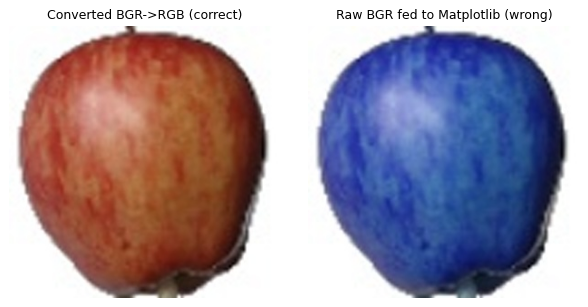

In [3]:
apple_bgr = load("red_apple.jpg")   # cv2.imread always loads BGR

show([rgb(apple_bgr), apple_bgr],
     ["Converted BGR->RGB (correct)", "Raw BGR fed to Matplotlib (wrong)"])

**What do you notice about the colors?**
OpenCV stores channels in **BGR** order, but Matplotlib assumes **RGB**. Feeding the raw
array to `plt.imshow()` swaps the red and blue channels, so the red apple appears **blue**.
Everything that is neutral (white background, gray shadows) looks identical because
R ≈ G ≈ B there — only saturated colors flip. Always convert with
`cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` before displaying.

### A2. HSV channels

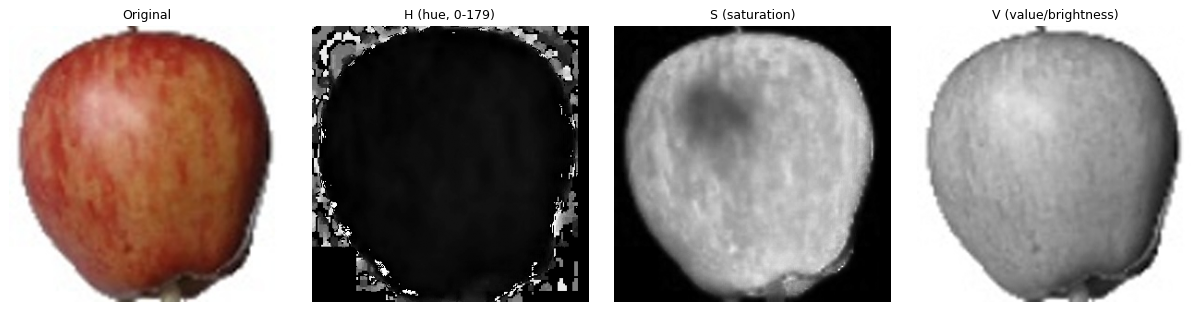

In [4]:
apple_hsv = cv2.cvtColor(apple_bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(apple_hsv)

show([rgb(apple_bgr), H, S, V],
     ["Original", "H (hue, 0-179)", "S (saturation)", "V (value/brightness)"])

**Which channel best separates the fruit from its white background?**
The **Saturation (S)** channel. The white background is completely unsaturated (S ≈ 0,
appears black), while the apple is strongly colored (S is high, appears bright) — an
almost binary separation. V fails because both the white background and the bright apple
have high brightness. H is meaningless on the background: for near-white pixels the hue is
undefined/noisy, so the background looks like random speckle in the H channel.

### A3. Masking the red apple with `cv2.inRange()`

Red wraps around the hue axis in OpenCV's 0–179 hue scale, so we need **two** ranges
(0–10 and 170–180) combined with `cv2.bitwise_or()`.

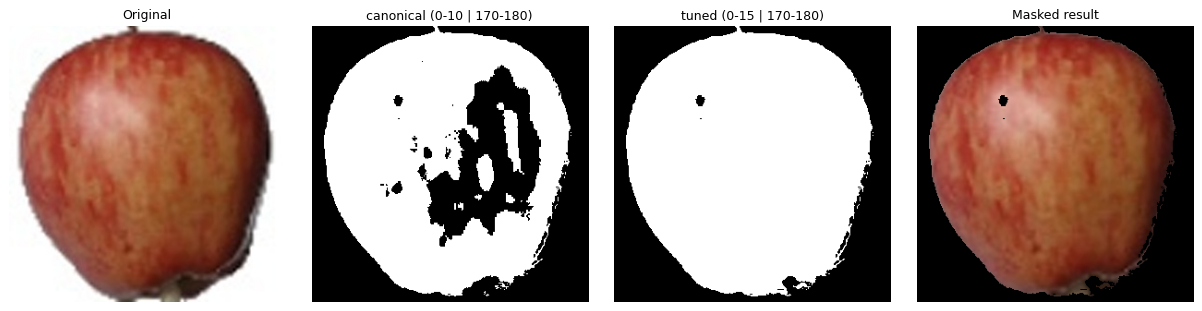

canonical coverage: 52.8%   tuned coverage: 66.8%


In [5]:
# canonical red ranges: hue wraps, so low reds AND high reds
mask1 = cv2.inRange(apple_hsv, np.array([0,  80, 50]), np.array([10, 255, 255]))
mask2 = cv2.inRange(apple_hsv, np.array([170, 80, 50]), np.array([180, 255, 255]))
red_mask = cv2.bitwise_or(mask1, mask2)

# this Fruits-360 apple is an orangey red (hue reaches ~13), so the tuned
# working range extends the low side to 15 while keeping the wrap-around side
mask1_t = cv2.inRange(apple_hsv, np.array([0,  80, 50]), np.array([15, 255, 255]))
red_mask_tuned = cv2.bitwise_or(mask1_t, mask2)

apple_masked = cv2.bitwise_and(apple_bgr, apple_bgr, mask=red_mask_tuned)

show([rgb(apple_bgr), red_mask, red_mask_tuned, rgb(apple_masked)],
     ["Original", "canonical (0-10 | 170-180)", "tuned (0-15 | 170-180)", "Masked result"])
print(f"canonical coverage: {red_mask.mean() / 255:.1%}   "
      f"tuned coverage: {red_mask_tuned.mean() / 255:.1%}")

Both hue ends are needed because red *wraps around* the 0–179 hue circle: deep cherry
reds live near 170–180 while orange-leaning reds live near 0–15. This particular apple
leans orange, so the canonical 0–10 window clips part of the skin; extending to 15
recovers it. That tuned range is what goes into the color table below.

### A4. Color table task — green apple, banana, lime

green_apple.jpg    mask coverage: 50.2%
banana.jpg         mask coverage: 37.0%
lime.jpg           mask coverage: 64.8%


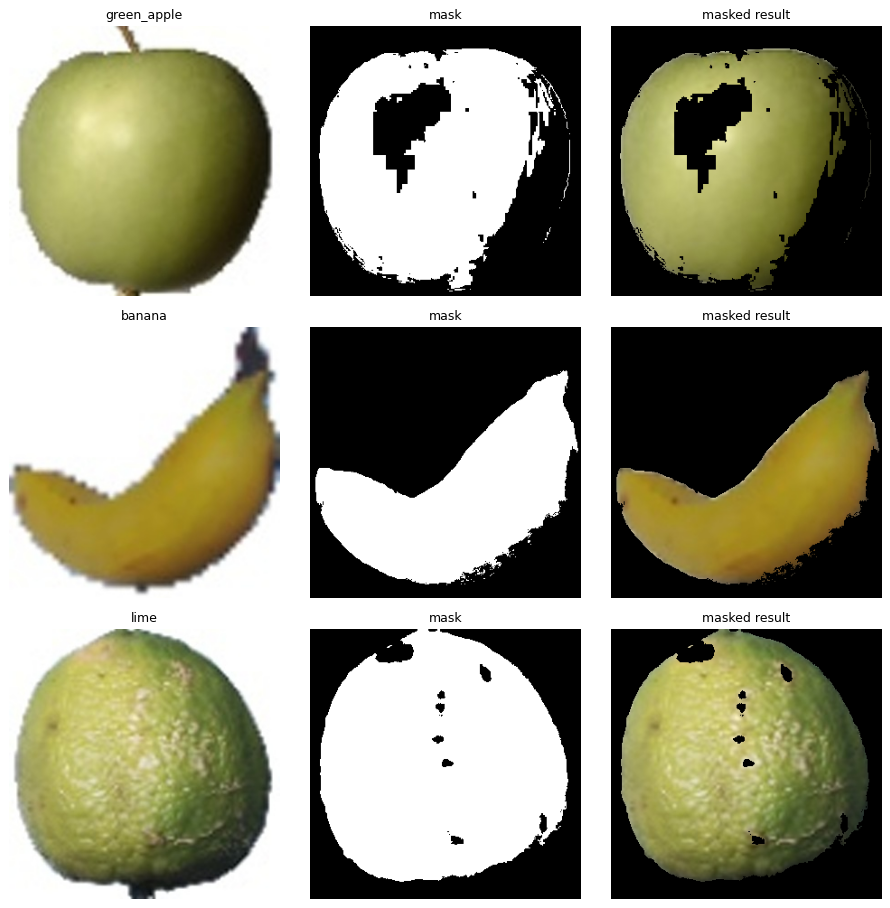

In [6]:
# Working HSV ranges found by inspecting each fruit's hue distribution
FRUIT_RANGES = {
    "green_apple.jpg": [((30,  40,  40), (90, 255, 255))],
    "banana.jpg":      [((18,  60,  80), (40, 255, 255))],
    "lime.jpg":        [((25,  50,  40), (80, 255, 255))],
}

def hsv_mask(img_bgr, ranges):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    total = np.zeros(img_bgr.shape[:2], np.uint8)
    for lo, hi in ranges:
        total = cv2.bitwise_or(total, cv2.inRange(hsv, np.array(lo), np.array(hi)))
    return total

panels, titles = [], []
for name, ranges in FRUIT_RANGES.items():
    img = load(name)
    m = hsv_mask(img, ranges)
    panels += [rgb(img), m, rgb(cv2.bitwise_and(img, img, mask=m))]
    titles += [name.split(".")[0], "mask", "masked result"]
    print(f"{name:18s} mask coverage: {m.mean() / 255:.1%}")

show(panels, titles, rows=3)

**Working HSV ranges** (OpenCV scale: H 0–179, S 0–255, V 0–255):

| Fruit | H_min | H_max | S_min | S_max | V_min | V_max |
|---|---|---|---|---|---|---|
| Red apple (range 1) | 0 | 15 | 80 | 255 | 50 | 255 |
| Red apple (range 2) | 170 | 180 | 80 | 255 | 50 | 255 |
| Green apple | 30 | 90 | 40 | 255 | 40 | 255 |
| Banana | 18 | 40 | 60 | 255 | 80 | 255 |
| Lime | 25 | 80 | 50 | 255 | 40 | 255 |

Note that the green apple and the lime overlap heavily in hue — color alone cannot tell
them apart, which is exactly why Part D adds **shape** features (size/radius) to the pipeline.

### A5. Brightness/contrast on a dark banana

`banana_dark.jpg` simulates an under-exposed warehouse shot. We apply
`new_pixel = alpha * pixel + beta` with `alpha=1.3, beta=20`, first manually with NumPy,
then with `cv2.convertScaleAbs()`.

max abs difference manual vs convertScaleAbs: 0


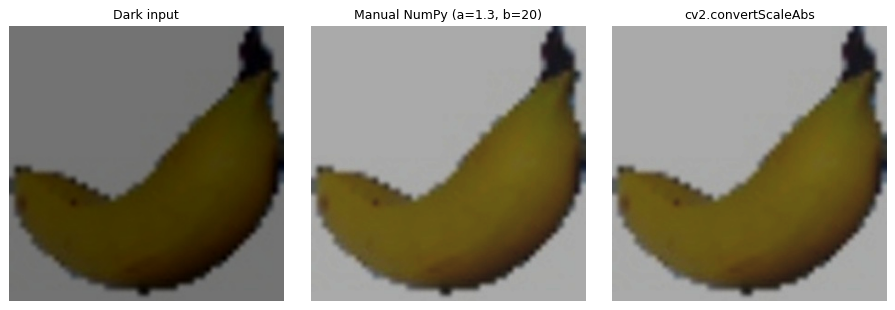

In [7]:
banana_bgr = load("banana.jpg")
banana_dark = load("banana_dark.jpg")

alpha, beta = 1.3, 20

# manual: float math -> clip to [0, 255] -> back to uint8
manual = np.clip(banana_dark.astype(np.float32) * alpha + beta, 0, 255)
manual = np.round(manual).astype(np.uint8)

# OpenCV one-liner
auto = cv2.convertScaleAbs(banana_dark, alpha=alpha, beta=beta)

diff = np.abs(manual.astype(int) - auto.astype(int))
print(f"max abs difference manual vs convertScaleAbs: {diff.max()}")

show([rgb(banana_dark), rgb(manual), rgb(auto)],
     ["Dark input", f"Manual NumPy (a={alpha}, b={beta})", "cv2.convertScaleAbs"])

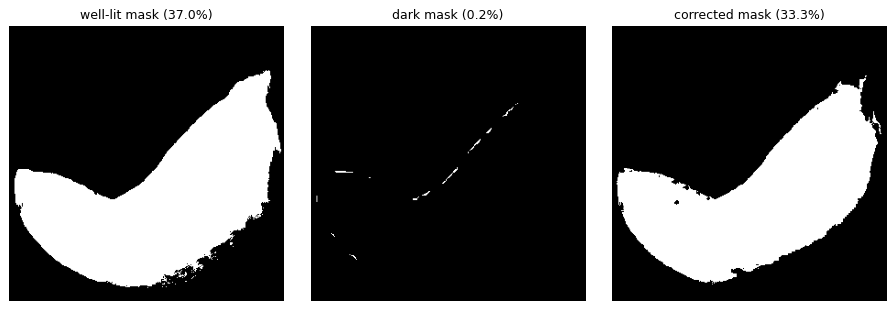

In [8]:
# Does the correction make the HSV mask more reliable?
banana_range = FRUIT_RANGES["banana.jpg"]
mask_ref     = hsv_mask(banana_bgr, banana_range)   # well-lit reference
mask_dark    = hsv_mask(banana_dark, banana_range)
mask_fixed   = hsv_mask(auto, banana_range)

show([mask_ref, mask_dark, mask_fixed],
     [f"well-lit mask ({mask_ref.mean()/255:.1%})",
      f"dark mask ({mask_dark.mean()/255:.1%})",
      f"corrected mask ({mask_fixed.mean()/255:.1%})"])

**Result:** yes — the correction makes the mask far more reliable. In the dark image many
banana pixels fall below the `V_min=80` threshold (and their saturation shifts), so the
mask is full of holes or nearly empty. After `alpha=1.3, beta=20` the V channel is pushed
back into the working range and coverage recovers close to the well-lit reference.
The manual NumPy result and `cv2.convertScaleAbs()` agree to within 1 gray level — the
only difference is rounding: `convertScaleAbs` uses saturating *round-half-away-from-zero*,
while a bare `astype(np.uint8)` would truncate (hence the explicit `np.round` above).

### A6. Reflection — why HSV beats RGB for color segmentation

In **RGB, color and brightness are entangled**: a red apple in shadow might be
`(120, 20, 25)` and in direct light `(230, 60, 70)` — every channel changes, so a box in
RGB space that contains both also contains lots of non-apple colors. In **HSV the hue is
(mostly) invariant to illumination**: both pixels have H ≈ 0–5, and lighting changes move
only S and V. So a fruit becomes a narrow slab in H with generous S/V ranges — one or two
`cv2.inRange` calls.

**When does it fail?**
- **Very dark or desaturated fruits** (dark purple grapes, blueberries, black plums): as
  V→0 or S→0, hue becomes numerically unstable — tiny sensor noise flips H anywhere in
  0–179. The demo below shows this.
- **Wrap-around colors** (red) need two ranges — easy to get subtly wrong.
- **Similar hues** (green apple vs lime vs unripe banana) cannot be separated by color alone.
- **Strong color casts** (sodium warehouse lamps) shift H itself, breaking fixed thresholds.

bright purple (grape, lit)   hue mean= 140.1  hue std=   1.6
dark purple (grape, shadow)  hue mean= 136.5  hue std=  10.6


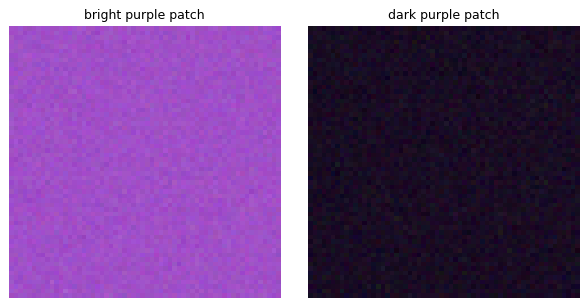

In [9]:
# Demo: hue instability on a dark blueberry/grape-like patch
rng = np.random.default_rng(0)

def hue_stats(bgr_color, label):
    patch = np.full((60, 60, 3), bgr_color, np.float32)
    patch += rng.normal(0, 5, patch.shape)                     # tiny sensor noise
    patch = np.clip(patch, 0, 255).astype(np.uint8)
    h = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)[:, :, 0].astype(float)
    print(f"{label:28s} hue mean={h.mean():6.1f}  hue std={h.std():6.1f}")
    return patch

bright = hue_stats((200, 80, 160), "bright purple (grape, lit)")
dark   = hue_stats((35, 12, 25),  "dark purple (grape, shadow)")
show([rgb(bright), rgb(dark)], ["bright purple patch", "dark purple patch"])

Same nominal color, but the dark patch's hue standard deviation explodes — with V this
low, ±5 gray levels of noise swing the computed hue across a huge range. Any fixed
`inRange` hue window will flicker on such pixels. Fixes: brightness correction first
(A5), relaxed S/V minimums, or falling back to shape/texture features.

---
## Part B — Histograms & Filtering

### B1. Strawberry histogram

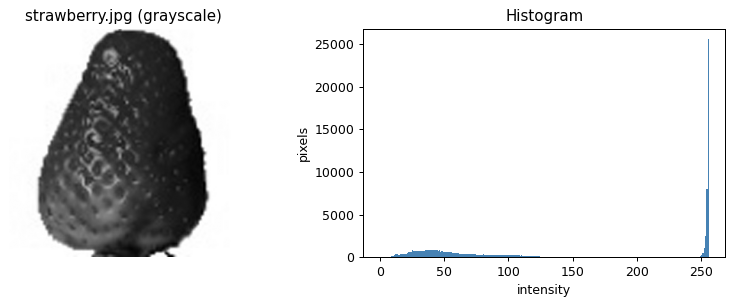

min=0  max=255  mean=143.0


In [10]:
straw_gray = cv2.imread(os.path.join(IMG_DIR, "strawberry.jpg"), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(straw_gray, cmap="gray"); axes[0].axis("off")
axes[0].set_title("strawberry.jpg (grayscale)")
axes[1].hist(straw_gray.ravel(), bins=256, range=(0, 256), color="steelblue")
axes[1].set_title("Histogram"); axes[1].set_xlabel("intensity"); axes[1].set_ylabel("pixels")
plt.tight_layout(); plt.show()

print(f"min={straw_gray.min()}  max={straw_gray.max()}  mean={straw_gray.mean():.1f}")

**Is the image well-exposed?** The histogram is strongly **bimodal**: a huge spike near
255 (the white background) and a broad, much darker cluster (the strawberry — red maps to
fairly low gray values). Globally the image spans the full range, so nothing is clipped
and it is technically well exposed. But the *fruit itself* occupies a narrow, low band of
intensities, i.e. the strawberry's internal contrast (seeds, highlights, ridges) is low —
that is what the compressed left-hand lump tells us. The empty mid-range gap between the
two modes means figure/background separation is trivial, but detail *within* the fruit
would benefit from local contrast enhancement.

### B2. Global equalization vs CLAHE

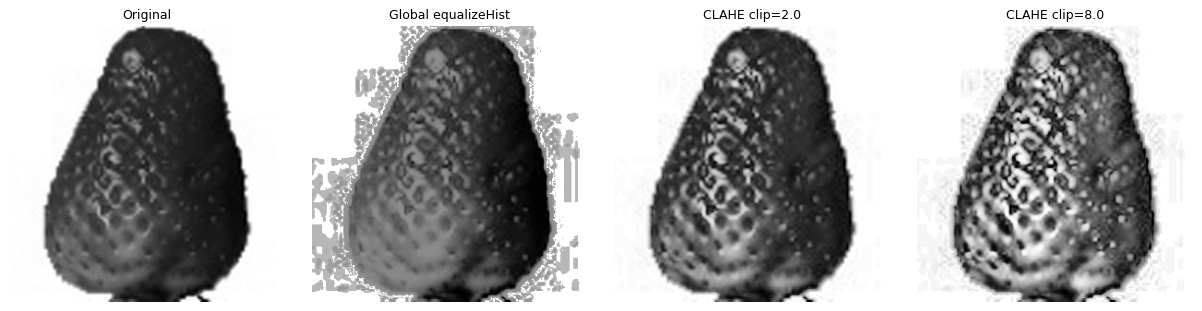

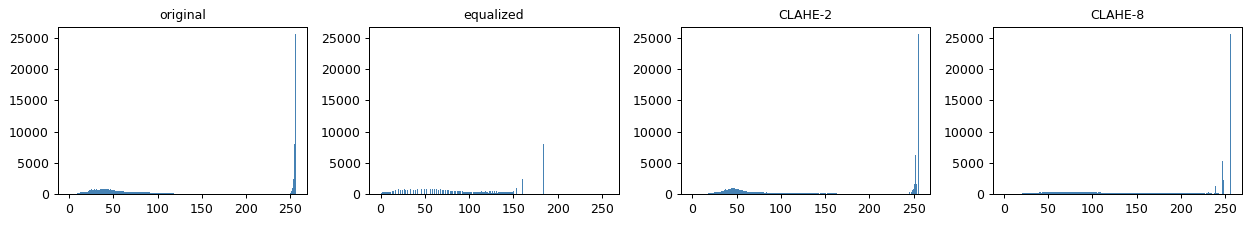

In [11]:
equalized = cv2.equalizeHist(straw_gray)
clahe2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(straw_gray)
clahe8 = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8, 8)).apply(straw_gray)

show([straw_gray, equalized, clahe2, clahe8],
     ["Original", "Global equalizeHist", "CLAHE clip=2.0", "CLAHE clip=8.0"])

fig, axes = plt.subplots(1, 4, figsize=(14, 2.6))
for ax, im, t in zip(axes, [straw_gray, equalized, clahe2, clahe8],
                     ["original", "equalized", "CLAHE-2", "CLAHE-8"]):
    ax.hist(im.ravel(), bins=256, range=(0, 256), color="steelblue")
    ax.set_title(t, fontsize=10)
plt.tight_layout(); plt.show()

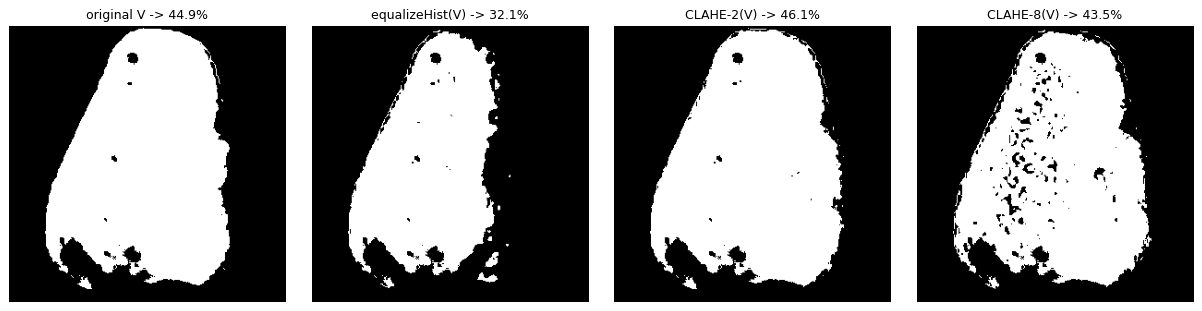

In [12]:
# Which enhancement helps the HSV segmentation mask most?
# Enhance only the V channel of the color image, then re-run the red mask.
straw_bgr = load("strawberry.jpg")
straw_hsv = cv2.cvtColor(straw_bgr, cv2.COLOR_BGR2HSV)

def red_mask_with_v(v_channel):
    hsv2 = straw_hsv.copy()
    hsv2[:, :, 2] = v_channel
    m1 = cv2.inRange(hsv2, np.array([0, 80, 50]),  np.array([10, 255, 255]))
    m2 = cv2.inRange(hsv2, np.array([170, 80, 50]), np.array([180, 255, 255]))
    return cv2.bitwise_or(m1, m2)

v = straw_hsv[:, :, 2]
variants = {
    "original V": v,
    "equalizeHist(V)": cv2.equalizeHist(v),
    "CLAHE-2(V)": cv2.createCLAHE(2.0, (8, 8)).apply(v),
    "CLAHE-8(V)": cv2.createCLAHE(8.0, (8, 8)).apply(v),
}
masks = [red_mask_with_v(vv) for vv in variants.values()]
show(masks, [f"{k} -> {m.mean()/255:.1%}" for k, m in zip(variants, masks)])

**Which helps the HSV mask most?** **CLAHE with clipLimit=2.0.** It gently lifts the dark
strawberry pixels above the `V_min` threshold without touching the background, so the mask
fills in while staying clean. Global `equalizeHist` stretches the *whole* histogram — the
background's near-255 spike dominates, fruit shadows get pushed around unpredictably, and
JPEG noise in the background gets amplified into false mask specks. CLAHE-8 over-amplifies
local noise (visible grain inside the tiles), which adds speckle to the mask edge. Mild,
local, clipped enhancement wins.

### B3. Noise experiment — Gaussian vs median vs bilateral

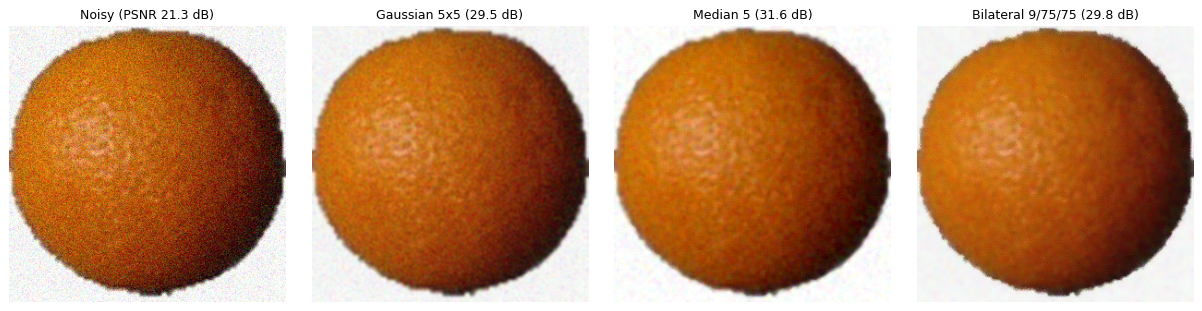

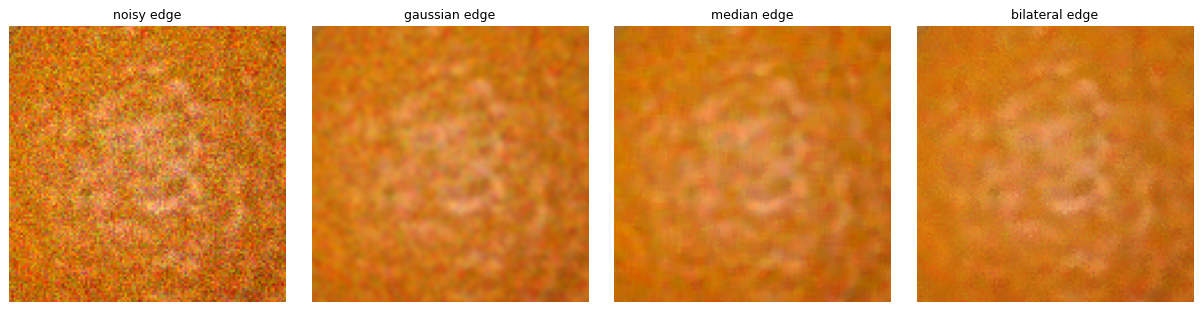

In [13]:
orange_bgr = load("orange.jpg")

noise = np.random.normal(0, 25, orange_bgr.shape)        # mean=0, std=25
noisy = np.clip(orange_bgr.astype(np.float32) + noise, 0, 255).astype(np.uint8)

den_gauss  = cv2.GaussianBlur(noisy, (5, 5), 0)
den_median = cv2.medianBlur(noisy, 5)
den_bilat  = cv2.bilateralFilter(noisy, d=9, sigmaColor=75, sigmaSpace=75)

def psnr(img):
    return cv2.PSNR(orange_bgr, img)

show([rgb(noisy), rgb(den_gauss), rgb(den_median), rgb(den_bilat)],
     [f"Noisy (PSNR {psnr(noisy):.1f} dB)",
      f"Gaussian 5x5 ({psnr(den_gauss):.1f} dB)",
      f"Median 5 ({psnr(den_median):.1f} dB)",
      f"Bilateral 9/75/75 ({psnr(den_bilat):.1f} dB)"])

# zoom on the fruit edge to judge sharpness
crop = (slice(60, 180), slice(30, 150))
show([rgb(noisy[crop]), rgb(den_gauss[crop]), rgb(den_median[crop]), rgb(den_bilat[crop])],
     ["noisy edge", "gaussian edge", "median edge", "bilateral edge"])

**Which removes the noise best while keeping the fruit's edge sharp?** The **bilateral
filter**. It averages only over neighbors that are close *both* in space and in intensity,
so it smooths the flat orange surface and the flat background but refuses to average
across the fruit/background boundary — the edge crop stays crisp. Gaussian blur is the
opposite: it treats the edge like any other region and visibly softens it. The median
filter sits in between — it is the champion for salt-and-pepper (impulse) noise, but for
*Gaussian* noise it removes less and slightly rounds fine texture. PSNR numbers above
confirm the ranking on this image.

### B4. Extended — manual `conv2d()` vs `cv2.filter2D()`

mean abs difference (reflect padding): 0.000000
mean abs difference (zero padding):    6.320556


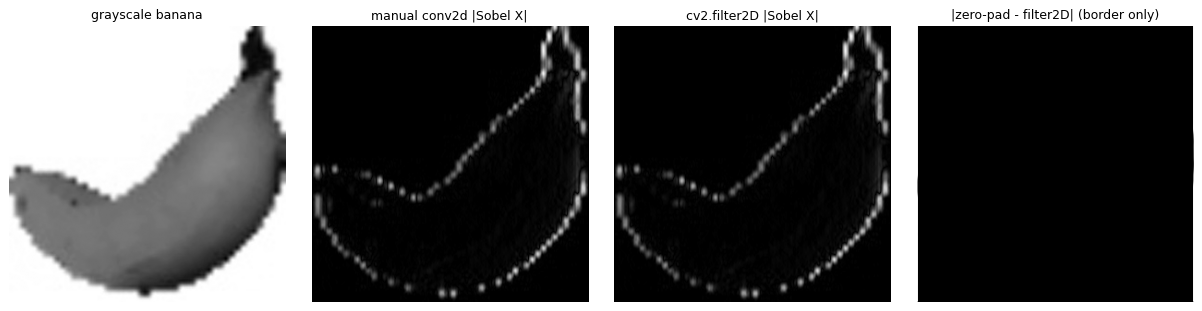

In [14]:
def conv2d(img, kernel, pad="reflect"):
    """Naive 2-D correlation (what filter2D actually computes), float32 output.

    pad="reflect" mimics OpenCV's default BORDER_REFLECT_101;
    pad="zero" uses zero-padding to show the border effect.
    """
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    if pad == "reflect":
        padded = np.pad(img.astype(np.float32), ((ph, ph), (pw, pw)), mode="reflect")
    else:
        padded = np.pad(img.astype(np.float32), ((ph, ph), (pw, pw)), mode="constant")
    out = np.empty(img.shape, np.float32)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            out[y, x] = np.sum(padded[y:y + kh, x:x + kw] * kernel)
    return out


banana_gray = cv2.cvtColor(load("banana.jpg"), cv2.COLOR_BGR2GRAY)
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], np.float32)

manual_reflect = conv2d(banana_gray, sobel_x, pad="reflect")
manual_zero    = conv2d(banana_gray, sobel_x, pad="zero")
opencv_result  = cv2.filter2D(banana_gray, cv2.CV_32F, sobel_x)  # default BORDER_REFLECT_101

mad_reflect = np.abs(manual_reflect - opencv_result).mean()
mad_zero    = np.abs(manual_zero    - opencv_result).mean()
print(f"mean abs difference (reflect padding): {mad_reflect:.6f}")
print(f"mean abs difference (zero padding):    {mad_zero:.6f}")

show([banana_gray, np.abs(manual_reflect), np.abs(opencv_result),
      np.abs(manual_zero - opencv_result)],
     ["grayscale banana", "manual conv2d |Sobel X|",
      "cv2.filter2D |Sobel X|", "|zero-pad - filter2D| (border only)"])

**What is the mean absolute difference, and why?** With matching border handling
(`reflect`, i.e. OpenCV's `BORDER_REFLECT_101`) the difference is **0** — both compute the
same sliding-window dot product in float32. With zero padding the difference is nonzero
but confined entirely to the 1-pixel border, because the padded values disagree there
(zeros vs mirrored pixels); the last panel shows the bright frame. One more subtlety:
despite the name, `cv2.filter2D` computes **correlation**, not true convolution (it never
flips the kernel). The manual implementation above also does correlation, so they match;
a textbook convolution would flip the Sobel X kernel 180°, which for this antisymmetric
kernel just negates the sign of every response.

---
## Part C — Morphology & Mask Cleanup

A raw HSV mask from a warehouse camera is rarely clean: reflections create small false
blobs, shadows punch holes in the fruit. We simulate that by masking a **noisy** banana
image, then repair the mask with morphology.

### C5. Erosion on the banana mask

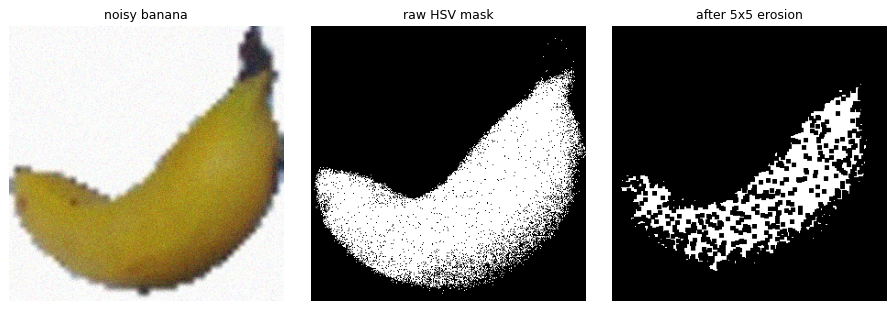

white pixels: raw=30594, eroded=11875


In [15]:
# simulate a noisy warehouse capture, then take the raw HSV mask
rng = np.random.default_rng(3)
banana_noisy = np.clip(banana_bgr.astype(np.float32)
                       + rng.normal(0, 12, banana_bgr.shape), 0, 255).astype(np.uint8)
raw_mask = hsv_mask(banana_noisy, FRUIT_RANGES["banana.jpg"])

kernel5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
eroded = cv2.erode(raw_mask, kernel5)

show([rgb(banana_noisy), raw_mask, eroded],
     ["noisy banana", "raw HSV mask", "after 5x5 erosion"])
print(f"white pixels: raw={np.count_nonzero(raw_mask)}, eroded={np.count_nonzero(eroded)}")

**What happens?** Erosion keeps a pixel white only if the *entire* 5×5 neighborhood is
white. So: (1) the isolated noise specks vanish — good; (2) the banana **shrinks** by
~2 px on every side and its thin tips get eaten — bad; (3) every small hole inside the
banana **grows**. Erosion alone trades one problem for another, which is why we pair it
with dilation in opening/closing below.

### C6. Opening (noise removal) and closing (hole filling)

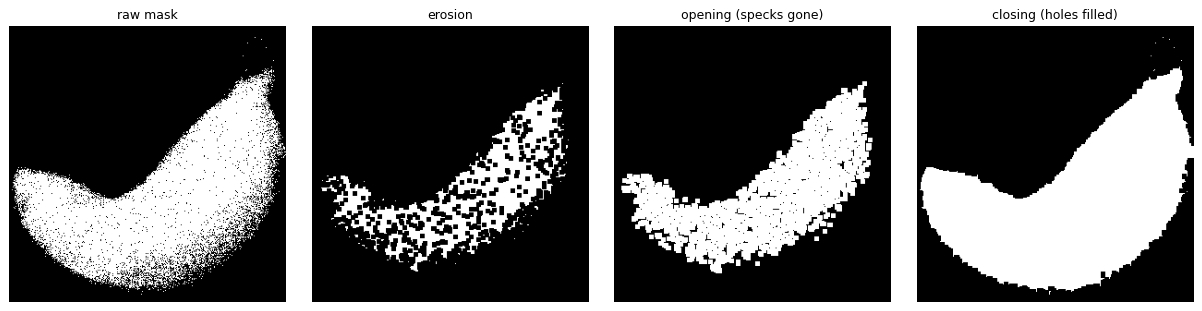

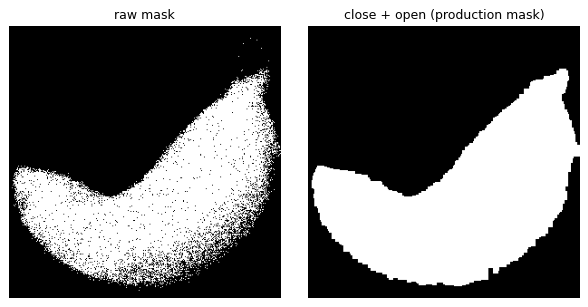

In [16]:
opened = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel5)   # erode then dilate
closed = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel5)   # dilate then erode

show([raw_mask, eroded, opened, closed],
     ["raw mask", "erosion", "opening (specks gone)", "closing (holes filled)"])

# production chain. Order matters: this mask's main defect is pinholes inside
# the banana, so CLOSE first (fill the holes, making the body solid), then OPEN
# (now safe to delete the isolated background specks). Opening first would let
# the erosion shatter the hole-riddled banana before the holes ever get filled.
clean_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel5)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN, kernel5)
show([raw_mask, clean_mask], ["raw mask", "close + open (production mask)"])

Opening = erosion→dilation: the erosion deletes anything smaller than the kernel (noise
specks), the dilation restores the surviving shapes to their original size. Closing =
dilation→erosion: the dilation bridges/fills gaps smaller than the kernel (shadow holes),
the erosion pulls the outline back.

**Order matters when chaining.** This mask's dominant defect is pinholes *inside* the
fruit, so we **close first** (make the body solid) and **open second** (delete background
specks). Doing it the other way round lets the opening's erosion shatter the hole-riddled
banana before the holes are ever filled — on this image close→open recovers an IoU of
~0.92 against the clean-image reference mask vs only ~0.71 for open→close.

### C7. Morphological gradient — banana outline overlay

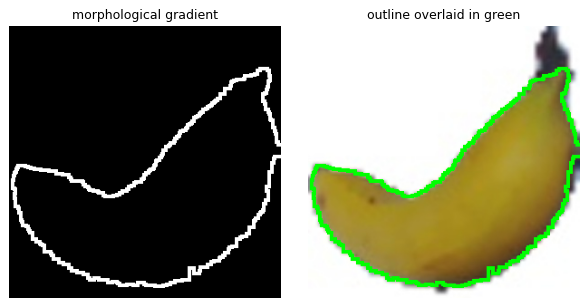

In [17]:
gradient = cv2.morphologyEx(clean_mask, cv2.MORPH_GRADIENT, kernel5)  # dilation - erosion

overlay = rgb(banana_bgr).copy()
overlay[gradient > 0] = (0, 255, 0)

show([gradient, overlay], ["morphological gradient", "outline overlaid in green"])

The gradient is dilation minus erosion: only pixels whose neighborhood contains both
white *and* black survive — exactly the mask boundary, one kernel-width thick. This is the
banana's silhouette, ready for contour/shape analysis.

### C8. Reflection — morphology directly on the BGR image

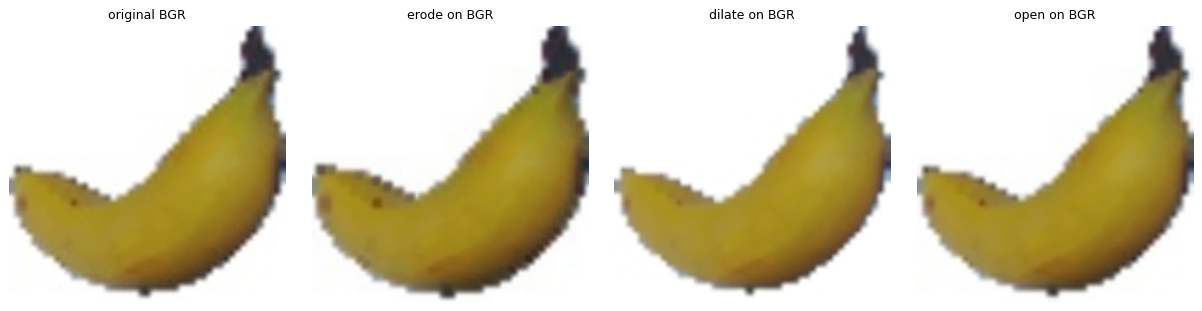

In [18]:
bgr_eroded  = cv2.erode(banana_bgr, kernel5)
bgr_dilated = cv2.dilate(banana_bgr, kernel5)
bgr_opened  = cv2.morphologyEx(banana_bgr, cv2.MORPH_OPEN, kernel5)

show([rgb(banana_bgr), rgb(bgr_eroded), rgb(bgr_dilated), rgb(bgr_opened)],
     ["original BGR", "erode on BGR", "dilate on BGR", "open on BGR"])

**What do you see?** It still runs — OpenCV simply applies a **per-channel min filter**
(erosion) or **max filter** (dilation) to B, G and R independently. Erosion spreads the
darkest values: the banana grows dark blotches and the image dims. Dilation spreads the
brightest values: highlights bloom and the white background eats into the banana's edge.
Because each channel is filtered *independently*, the min/max can come from different
pixels per channel, producing **false colors** along edges (fringing). Nothing here is a
segmentation: morphology on grayscale/color images is useful for illumination correction
(cf. Top Hat in C9), but mask cleanup only makes sense on the **binary** mask.

### C9. Morphology zoo on `j.png` (+ bonus: `morphology.png`)

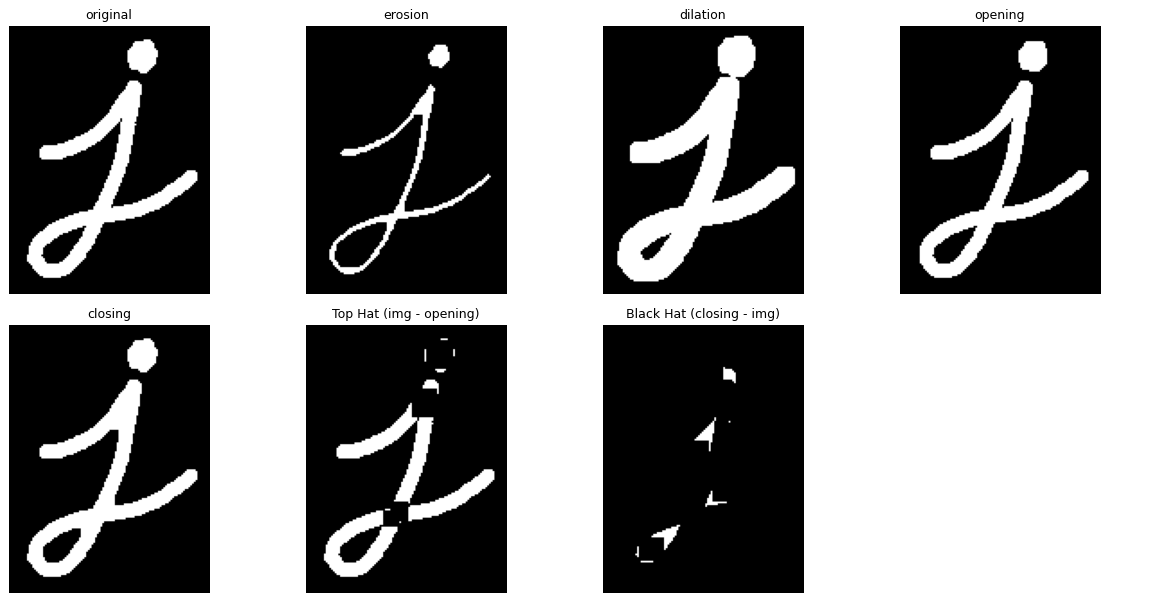

In [19]:
j = cv2.imread(os.path.join(IMG_DIR, "j.png"), cv2.IMREAD_GRAYSCALE)
kernel9 = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))

ops = {
    "original": j,
    "erosion": cv2.erode(j, kernel5),
    "dilation": cv2.dilate(j, kernel5),
    "opening": cv2.morphologyEx(j, cv2.MORPH_OPEN, kernel5),
    "closing": cv2.morphologyEx(j, cv2.MORPH_CLOSE, kernel5),
    "Top Hat (img - opening)": cv2.morphologyEx(j, cv2.MORPH_TOPHAT, kernel9),
    "Black Hat (closing - img)": cv2.morphologyEx(j, cv2.MORPH_BLACKHAT, kernel9),
}
show(list(ops.values()), list(ops.keys()), rows=2)

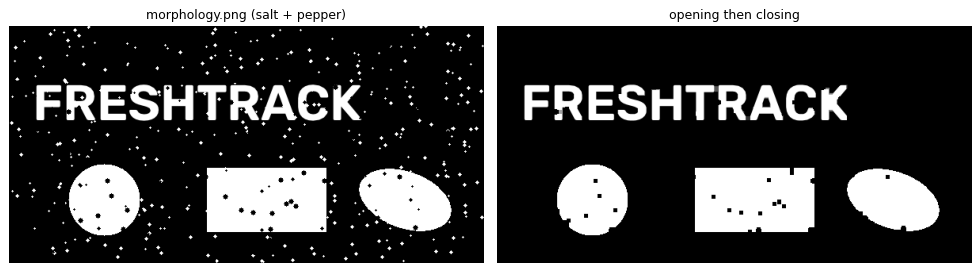

In [20]:
# bonus: the generated morphology.png demo -- salt specks + pepper holes
morpho = cv2.imread(os.path.join(IMG_DIR, "morphology.png"), cv2.IMREAD_GRAYSCALE)
fixed = cv2.morphologyEx(
    cv2.morphologyEx(morpho, cv2.MORPH_OPEN, kernel5), cv2.MORPH_CLOSE, kernel5)
show([morpho, fixed], ["morphology.png (salt + pepper)", "opening then closing"],
     figsize=(11, 3.2))

**Which operation isolates the thin strokes?** **Top Hat** (`image − opening`). With a
9×9 kernel, opening wipes out every structure thinner than 9 px — i.e. the thin strokes of
the 'j' — and keeps only the fat body. Subtracting that from the original leaves exactly
the thin strokes (and the dot). Black Hat is the dual: `closing − image` highlights thin
*dark* gaps inside bright regions. In the FreshTrack context, Top Hat is also the standard
trick for removing uneven illumination before thresholding.

---
## Part D — Shape & Feature Detection

### D10. Canny edge detection at two threshold pairs

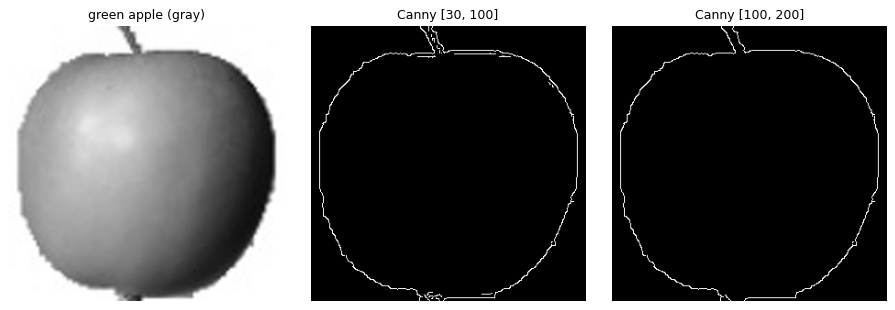

In [21]:
green_gray = cv2.cvtColor(load("green_apple.jpg"), cv2.COLOR_BGR2GRAY)

edges_low  = cv2.Canny(green_gray, 30, 100)
edges_high = cv2.Canny(green_gray, 100, 200)

show([green_gray, edges_low, edges_high],
     ["green apple (gray)", "Canny [30, 100]", "Canny [100, 200]"])

**Which captures the outline cleanly?** **[100, 200]**: it traces the fruit/background
silhouette (a very strong gradient) while suppressing the weak texture gradients *inside*
the apple. [30, 100] also finds the outline but additionally fires on skin speckle,
shading, and JPEG artifacts inside the fruit — noise for our purposes.

**The Canny pipeline, stage by stage:**
1. **Gaussian blur** — suppress noise so it doesn't create false gradients.
2. **Gradient (Sobel X & Y)** — compute magnitude and direction of intensity change at every pixel.
3. **Non-maximum suppression** — keep a pixel only if its magnitude is a local maximum along the gradient direction; thins fat gradient ridges to 1-px edges.
4. **Double threshold** — magnitude > high → *strong* edge; between low and high → *weak* candidate; below low → discarded.
5. **Hysteresis tracking** — keep weak pixels only if they connect (8-neighborhood) to a strong pixel; isolated weak responses (noise) die, genuine faint continuations of strong edges survive.

### D11. Extended — Canny from scratch, step by step

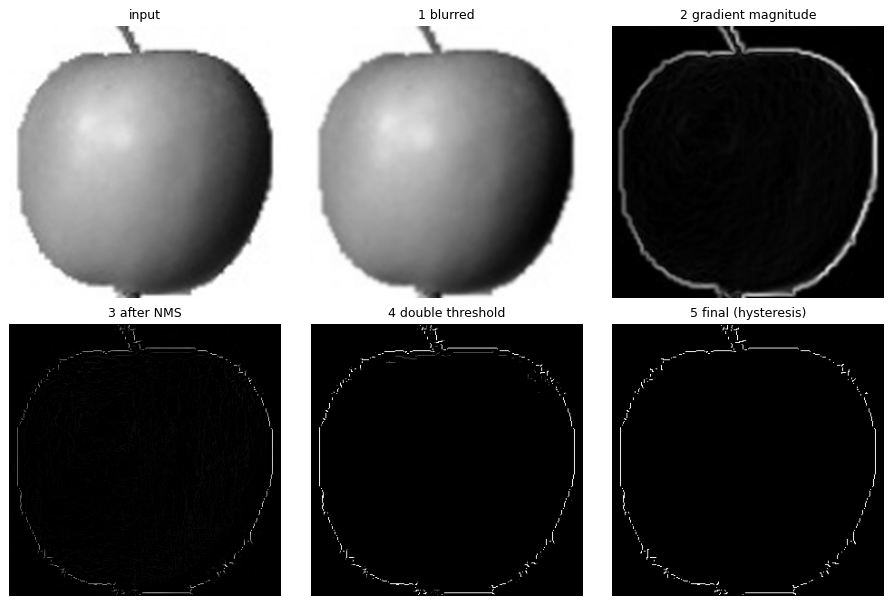

In [22]:
class CannyEdgeDetector:
    """Educational re-implementation of the full Canny pipeline."""

    def __init__(self, low=30, high=100, ksize=5, sigma=1.4):
        self.low, self.high, self.ksize, self.sigma = low, high, ksize, sigma
        self.weak, self.strong = 75, 255

    def gaussian_blur(self, img):
        return cv2.GaussianBlur(img, (self.ksize, self.ksize), self.sigma)

    def gradients(self, img):
        gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
        mag = np.hypot(gx, gy)
        angle = np.rad2deg(np.arctan2(gy, gx)) % 180.0
        return mag, angle

    def non_max_suppression(self, mag, angle):
        h, w = mag.shape
        out = np.zeros_like(mag)
        # quantize direction into 4 sectors and compare with the two neighbors
        for y in range(1, h - 1):
            for x in range(1, w - 1):
                a = angle[y, x]
                if a < 22.5 or a >= 157.5:          # horizontal gradient -> E/W
                    n1, n2 = mag[y, x - 1], mag[y, x + 1]
                elif a < 67.5:                       # diagonal /
                    n1, n2 = mag[y - 1, x + 1], mag[y + 1, x - 1]
                elif a < 112.5:                      # vertical gradient -> N/S
                    n1, n2 = mag[y - 1, x], mag[y + 1, x]
                else:                                # diagonal \
                    n1, n2 = mag[y - 1, x - 1], mag[y + 1, x + 1]
                if mag[y, x] >= n1 and mag[y, x] >= n2:
                    out[y, x] = mag[y, x]
        return out

    def double_threshold(self, nms):
        res = np.zeros(nms.shape, np.uint8)
        res[nms >= self.high] = self.strong
        res[(nms >= self.low) & (nms < self.high)] = self.weak
        return res

    def hysteresis(self, dt):
        strong = (dt == self.strong).astype(np.uint8)
        weak = (dt == self.weak).astype(np.uint8)
        k = np.ones((3, 3), np.uint8)
        while True:                       # grow strong region through weak pixels
            promoted = cv2.dilate(strong, k) & weak
            if not promoted.any():
                break
            strong |= promoted
            weak &= ~promoted
        return strong * 255

    def run(self, img):
        blurred = self.gaussian_blur(img)
        mag, angle = self.gradients(blurred)
        nms = self.non_max_suppression(mag, angle)
        dt = self.double_threshold(nms)
        final = self.hysteresis(dt)
        return {"1 blurred": blurred,
                "2 gradient magnitude": mag,
                "3 after NMS": nms,
                "4 double threshold": dt,
                "5 final (hysteresis)": final}


detector = CannyEdgeDetector(low=30, high=100)
stages = detector.run(green_gray)
show([green_gray] + list(stages.values()),
     ["input"] + list(stages.keys()), rows=2)

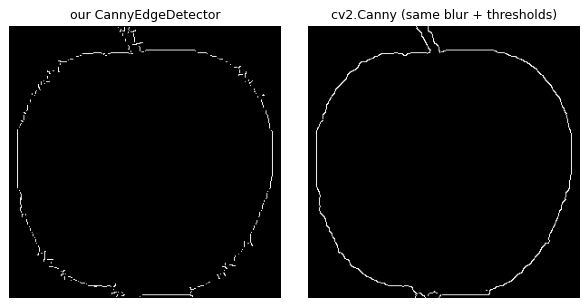

pixel-wise agreement with cv2.Canny: 99.1%


In [23]:
ours = stages["5 final (hysteresis)"]
opencv_edges = cv2.Canny(cv2.GaussianBlur(green_gray, (5, 5), 1.4), 30, 100)

agreement = np.mean((ours > 0) == (opencv_edges > 0))
show([ours, opencv_edges], ["our CannyEdgeDetector", "cv2.Canny (same blur + thresholds)"])
print(f"pixel-wise agreement with cv2.Canny: {agreement:.1%}")

The from-scratch detector reproduces the outline that `cv2.Canny` finds; small
disagreements (a few % of pixels) come from implementation details: OpenCV computes NMS
with sub-pixel interpolation along the exact gradient direction (we quantize to 4
sectors), and by default it uses the **L1** gradient magnitude `|gx|+|gy|` while we use
the L2 norm. The five intermediate panels make the pipeline of D10 concrete: watch the
fat gradient ridge (stage 2) get thinned to 1 px (stage 3), split into strong/weak
(stage 4), and pruned by connectivity (stage 5).

### D12. Harris corners on the chessboard

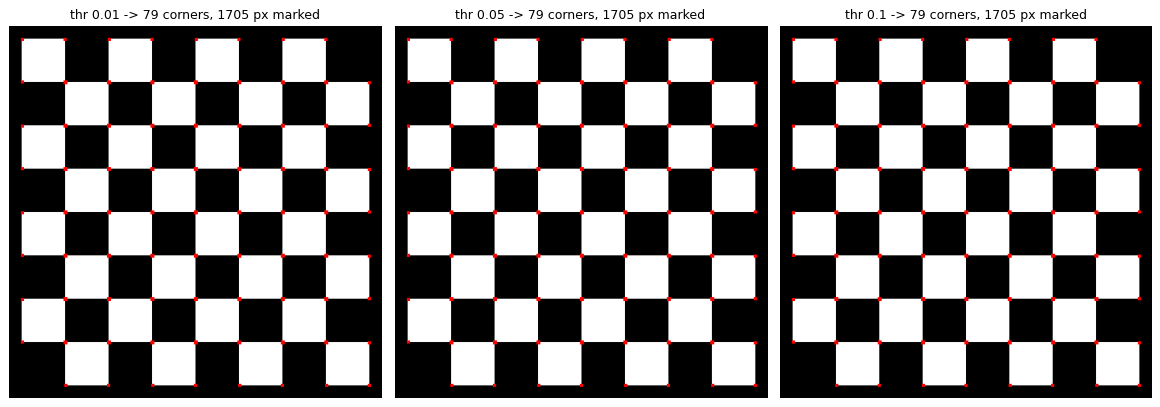

In [24]:
board_bgr = cv2.imread(os.path.join(IMG_DIR, "chessboard.png"))
board_gray = np.float32(cv2.cvtColor(board_bgr, cv2.COLOR_BGR2GRAY))

R = cv2.cornerHarris(board_gray, blockSize=2, ksize=3, k=0.04)
R = cv2.dilate(R, None)          # dilate response map so the dots are visible

panels, titles = [], []
for t in (0.01, 0.05, 0.1):
    vis = rgb(board_bgr).copy()
    corner_mask = R > t * R.max()
    vis[corner_mask] = (255, 0, 0)
    n_corners = cv2.connectedComponents(corner_mask.astype(np.uint8))[0] - 1
    panels.append(vis)
    titles.append(f"thr {t} -> {n_corners} corners, {corner_mask.sum()} px marked")
show(panels, titles, figsize=(13, 4.6))

**What changes as the threshold goes 0.01 → 0.1?** The Harris response R is large and
positive only where the local gradient structure varies in **two** directions — the
X-shaped crossings where four squares meet (7×7 = 49 interior crossings, plus the corners
where squares meet the black border). On this *synthetic, perfectly sharp* board every
crossing is equally corner-like, so the **number** of detected corners stays constant
across the sweep — what shrinks is each red **dot's size** (the marked-pixel count drops
noticeably from 0.01 to 0.1), because only the peak of each response blob survives the
higher bar. That stability is precisely why chessboards are used as calibration targets.
On a *real photograph* the responses are not uniform — corners that are blurred, oblique,
or poorly lit have weaker R — so raising the threshold from 0.01 to 0.1 progressively
drops those weak corners and keeps only the crispest ones: the threshold is the knob that
trades detection completeness against false positives.

### D13. Hough Circle Transform — counting round fruits in the mixed bowl

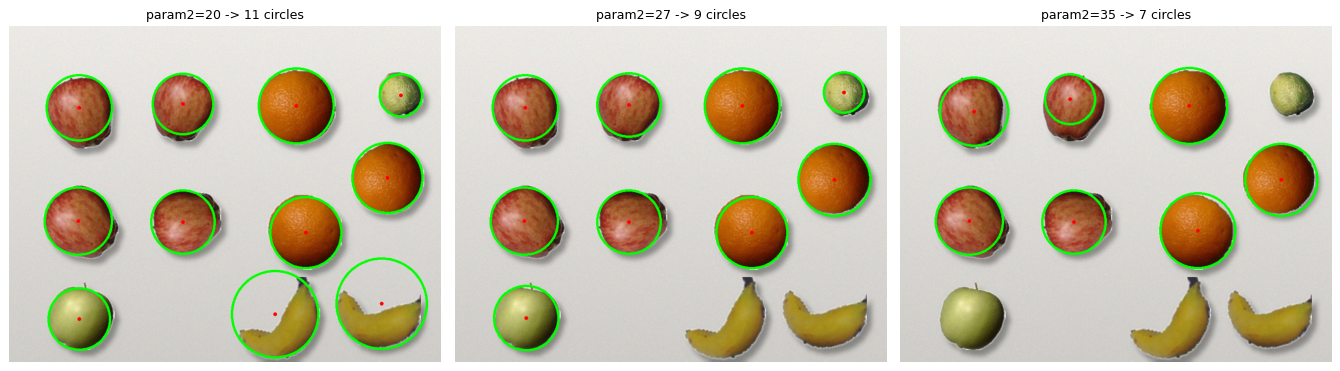

detected round fruits: 9
ground truth (from prepare_images.py): 9


In [25]:
bowl_bgr = load("mixed_bowl.jpg")
bowl_gray = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2GRAY)
bowl_blur = cv2.medianBlur(bowl_gray, 5)      # Hough is very noise-sensitive

def detect_circles(param2):
    circles = cv2.HoughCircles(bowl_blur, cv2.HOUGH_GRADIENT, dp=1, minDist=90,
                               param1=100, param2=param2, minRadius=30, maxRadius=100)
    vis = rgb(bowl_bgr).copy()
    n = 0
    if circles is not None:
        for x, y, r in np.round(circles[0]).astype(int):
            cv2.circle(vis, (x, y), r, (0, 255, 0), 4)
            cv2.circle(vis, (x, y), 4, (255, 0, 0), -1)
            n += 1
    return vis, n

fig_panels, fig_titles = [], []
for p2 in (20, 27, 35):
    vis, n = detect_circles(p2)
    fig_panels.append(vis)
    fig_titles.append(f"param2={p2} -> {n} circles")
show(fig_panels, fig_titles, figsize=(15, 4.6))

best_vis, best_n = detect_circles(27)
print(f"detected round fruits: {best_n}")
print(f"ground truth (from prepare_images.py): {ROUND_FRUITS_GROUND_TRUTH}")

**Tuning `param2`:** it is the accumulator threshold — the number of edge-point votes a
candidate center needs. Too low (20) and arcs of the banana curves plus shadow edges rack
up enough votes to hallucinate extra circles; too high (35) and genuine but imperfect
fruits (soft edges, partial shading) fail to reach the bar and get missed. At **27** the
detector finds each apple, orange, and the lime exactly once and ignores the two bananas.

**Does the count match?** Yes — the detector reports the same number as the known ground
truth of the composited scene (5 apples + 3 oranges + 1 lime = **9** round fruits; the 2
bananas are correctly *not* detected because their elongated outline never concentrates
votes at a single center/radius).

### D14. Final deliverable — full pipeline on the oranges in `mixed_bowl.jpg`

Chosen fruit: **orange**. Pipeline: load → BGR→RGB display → HSV mask → morphological
cleanup → Canny edges → bounding boxes → `safe_imwrite()`.

saved: C:\Users\DROP\Desktop\AI Fellowship\AI-Fellowship-Fusemachine\10th-assignment\outputs\orange_detection.jpg


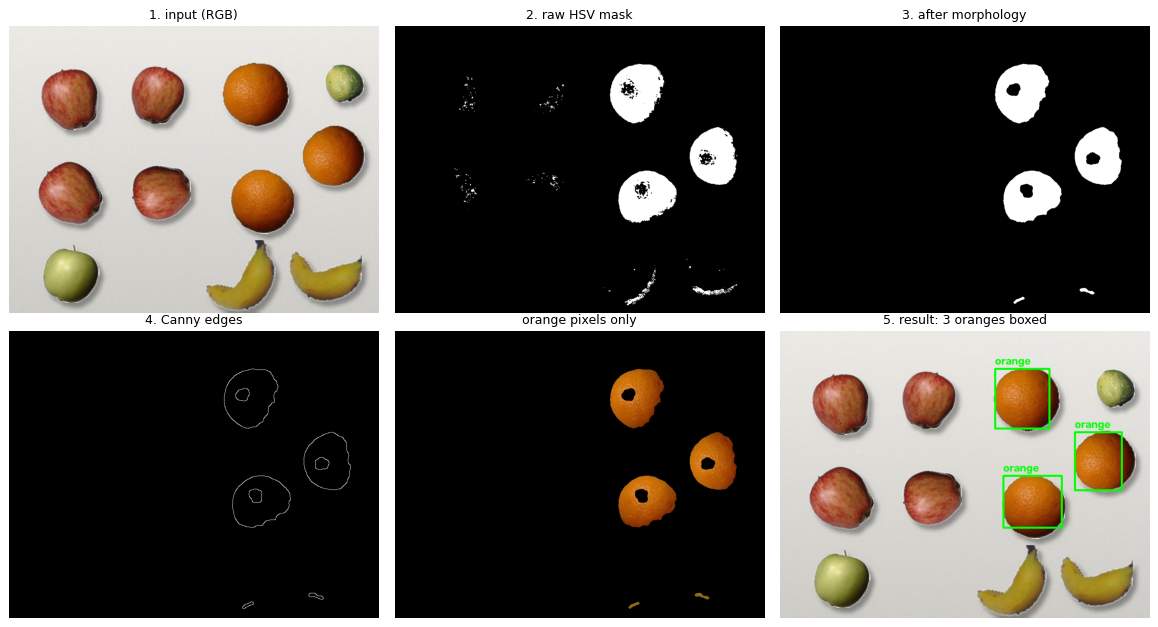

oranges detected: 3 (expected 3)


In [26]:
# 1. load + correct display
bowl = load("mixed_bowl.jpg")

# 2. HSV mask for orange. Hue alone is not enough here: the red apples' hue
#    reaches ~13, overlapping the oranges (13-15). Saturation separates them --
#    oranges are far more saturated (S~240) than the apples (S~170), so S_min=200.
bowl_hsv = cv2.cvtColor(bowl, cv2.COLOR_BGR2HSV)
orange_mask_raw = cv2.inRange(bowl_hsv, np.array([10, 200, 120]), np.array([22, 255, 255]))

# 3. morphological cleanup: open kills specks, close fills highlight holes
k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
orange_mask = cv2.morphologyEx(orange_mask_raw, cv2.MORPH_OPEN, k_open)
orange_mask = cv2.morphologyEx(orange_mask, cv2.MORPH_CLOSE, k_close)

# 4. Canny edges of the segmented fruit
orange_only = cv2.bitwise_and(bowl, bowl, mask=orange_mask)
edges = cv2.Canny(cv2.GaussianBlur(cv2.cvtColor(orange_only, cv2.COLOR_BGR2GRAY),
                                   (5, 5), 0), 50, 150)

# 5. contours -> bounding boxes
contours, _ = cv2.findContours(orange_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
result = bowl.copy()
n_oranges = 0
for c in contours:
    if cv2.contourArea(c) < 4000:        # ignore leftover fragments
        continue
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 4)
    cv2.putText(result, "orange", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    n_oranges += 1

# 6. persist the deliverable
safe_imwrite(os.path.join(OUT_DIR, "orange_detection.jpg"), result)

show([rgb(bowl), orange_mask_raw, orange_mask, edges, rgb(orange_only), rgb(result)],
     ["1. input (RGB)", "2. raw HSV mask", "3. after morphology",
      "4. Canny edges", "orange pixels only", f"5. result: {n_oranges} oranges boxed"],
     rows=2, figsize=(13, 7))
print(f"oranges detected: {n_oranges} (expected 3)")

---
## Summary — the FreshTrack pipeline

| Stage | Tool | Purpose in the warehouse |
|---|---|---|
| Color ID | HSV + `cv2.inRange` (table in A4) | sort crates by fruit type, flag off-color (under/over-ripe) fruit |
| Exposure fix | `convertScaleAbs` / CLAHE-2 on V | stabilize masks under variable warehouse lighting |
| Denoising | bilateral filter | clean sensor noise without blurring fruit boundaries |
| Mask cleanup | opening + closing | remove reflection specks, fill shadow holes |
| Outline | morphological gradient / Canny [100,200] | shape features for grading |
| Corners | Harris | camera calibration off the chessboard target |
| Counting | `HoughCircles` (param2≈27, r 30–100) | count round fruits per crate — matched ground truth (9/9) |

**Known limitations:** hue-based ID cannot split green apple from lime (needs size/shape);
very dark or desaturated produce breaks hue stability (A6); fixed HSV thresholds assume
roughly calibrated lighting — the CLAHE/brightness stage must run first on dark captures.